In [2]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip'
data_path = '/content/drive/MyDrive/AI ML/Data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip' to '/content/drive/MyDrive/AI ML'


In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

# Set paths to your already extracted folders
train_dir = "/content/drive/MyDrive/AI ML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI ML/FruitinAmazon/test"

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [6]:
class_names = sorted(os.listdir(train_dir))
print(f"Classes: {class_names}")

# Check and remove corrupted files
for folder in [train_dir, test_dir]:
    for cls in class_names:
        path = os.path.join(folder, cls)
        for file in os.listdir(path):
            file_path = os.path.join(path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                print(f"Removing corrupted image: {file_path}")
                os.remove(file_path)

# Distribution check
for cls in class_names:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count} images")

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
acai: 15 images
cupuacu: 15 images
graviola: 15 images
guarana: 15 images
pupunha: 15 images
tucuma: 15 images


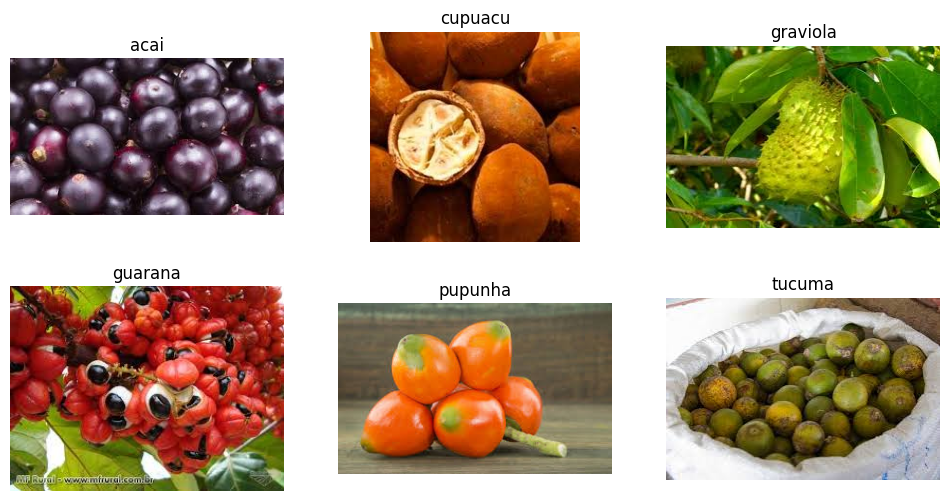

In [7]:
plt.figure(figsize=(12, 6))
for i, cls in enumerate(class_names):
    folder = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img = plt.imread(os.path.join(folder, img_name))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.show()

**Task 1: Improved CNN trained from scratch**

In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_ds = keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [9]:
model_scratch = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_aug,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model_scratch.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_scratch = model_scratch.fit(train_ds, validation_data=val_ds, epochs=15)

# Saving and Reloading the model
model_scratch.save('custom_fruit_model.h5')
reloaded_model = keras.models.load_model('custom_fruit_model.h5')

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 717ms/step - accuracy: 0.3750 - loss: 11.9170 - val_accuracy: 0.2778 - val_loss: 1.7119
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 764ms/step - accuracy: 0.4306 - loss: 14.5868 - val_accuracy: 0.2778 - val_loss: 1.6003
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5278 - loss: 12.4869 - val_accuracy: 0.1111 - val_loss: 2.8644
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6667 - loss: 9.2656 - val_accuracy: 0.2222 - val_loss: 4.3406
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7222 - loss: 5.2167 - val_accuracy: 0.2222 - val_loss: 5.3443
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 970ms/step - accuracy: 0.6944 - loss: 4.1759 - val_accuracy: 0.2222 - val_loss: 6.7364
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 663ms/step - accuracy: 0.7222 - loss: 4.6222 - val_accuracy: 0.2222 - val_loss: 10.4428
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 755ms/step - accuracy: 0.7083 - loss: 3.7298 - val_accuracy: 0.2222 - val_loss: 18.

**Task 2: Transfer Learning with VGG16**

In [10]:
VGG_SIZE = (224, 224)

train_vgg = keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=42,
    image_size=VGG_SIZE, batch_size=BATCH_SIZE
)

val_vgg = keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=42,
    image_size=VGG_SIZE, batch_size=BATCH_SIZE
)

# Load base model with ImageNet weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Custom classification head
model_vgg = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_vgg = model_vgg.fit(train_vgg, validation_data=val_vgg, epochs=10)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 83s 17s/step - accuracy: 0.2361 - loss: 8.6618 - val_accuracy: 0.4444 - val_loss: 3.0133
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 73s 15s/step - accuracy: 0.5278 - loss: 4.6247 - val_accuracy: 0.6111 - val_loss: 2.6611
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 75s 13s/step - accuracy: 0.7222 - loss: 2.6774 - val_accuracy: 0.6667 - val_loss: 2.5475
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 72s 15s/step - accuracy: 0.7500 - loss: 1.5020 - val_accuracy: 0.7778 - val_loss: 0.9957
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 75s 13s/step - accuracy: 0.8333 - loss: 0.7043 - val_accuracy: 0.8889 - val_loss: 0.5017
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 72s 15s/step - accuracy: 0.8194 - loss: 0.8398 - val_accuracy: 0.8889 - val_loss: 0.5134
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 75s 13s/step - accuracy: 

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 11s/step

--- Final Classification Report (VGG16) ---
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         5
     cupuacu       1.00      0.60      0.75         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.40      0.40      0.40         5
      tucuma       0.38      0.60      0.46         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.75        30
weighted avg       0.80      0.73      0.75        30



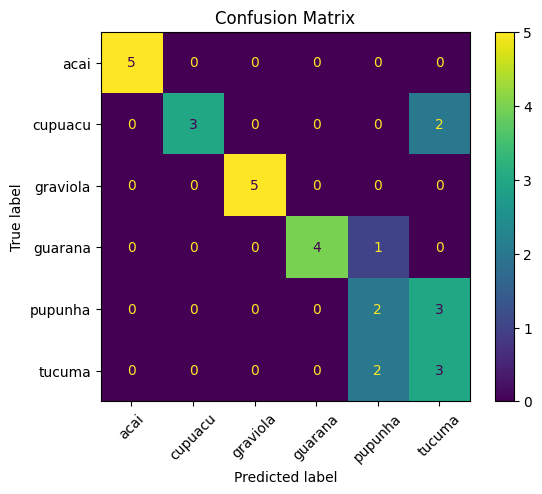

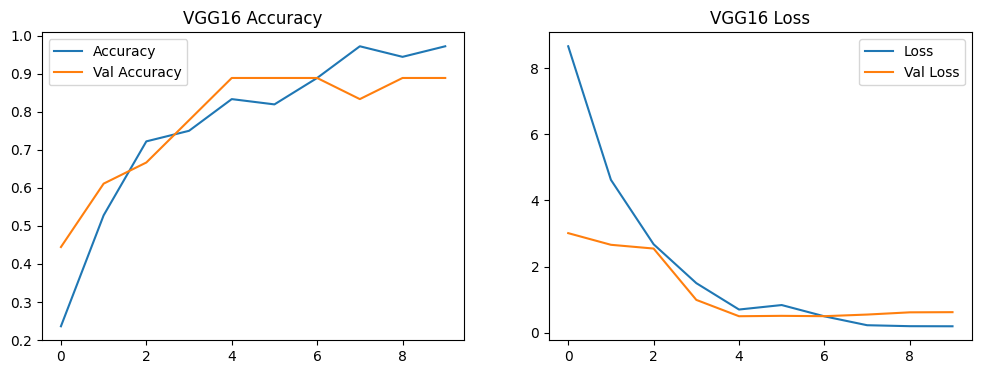

In [11]:
test_ds_vgg = keras.utils.image_dataset_from_directory(
    test_dir, image_size=VGG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

# 5.1 Predictions and Classification Report
y_true = np.concatenate([y for x, y in test_ds_vgg], axis=0)
y_pred = np.argmax(model_vgg.predict(test_ds_vgg), axis=1)

print("\n--- Final Classification Report (VGG16) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5.2 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# 5.3 Plotting Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Loss')
plt.plot(history_vgg.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss')
plt.legend()
plt.show()